In [1]:
import os
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool

from helpers.db_query import query_db

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DB_PATH = Path(
    os.environ.get(
        "FF_DB_PATH",
        r"C:\Users\terre\OneDrive\Desktop\Projects\Fantasy_Football_Database\data\fantasy_football.db",
    )
)
assert DB_PATH.exists(), f"DB not found: {DB_PATH}"
print(DB_PATH, f"{DB_PATH.stat().st_size / 1e6:.1f} MB")

C:\Users\terre\OneDrive\Desktop\Projects\Fantasy_Football_Database\data\fantasy_football.db 52.2 MB


In [2]:
# 2020 is pulled only to supply prior-season features for 2021 — it is not
# trained on directly, since 2019 is not in the database.
games_query = """
SELECT *
FROM v_player_games
WHERE season_type = 2
  AND season BETWEEN 2020 AND 2025
ORDER BY athlete_id, season, week
"""
df = query_db(games_query)
df["game_date"] = pd.to_datetime(df["game_date"])
df = df.drop(columns=["raw_stats", "loaded_at"])
df


,display_name,position_abbr,athlete_id,event_id,season,season_type,week,game_date,team_id,team_abbr,opponent_id,opponent_abbr,home_away,result,team_score,opponent_score,is_all_star,fp_standard,fp_half_ppr,fp_ppr,fumbles,fumblesForced,fumblesLost,kicksBlocked,longReception,longRushing,receivingTargets,receivingTouchdowns,receivingYards,receptions,rushingAttempts,rushingTouchdowns,rushingYards,yardsPerReception,yardsPerRushAttempt,QBRating,adjQBR,completionPct,completions,interceptions,longPassing,passingAttempts,passingTouchdowns,passingYards,sacks,yardsPerPassAttempt
0,Adrian Peterson,RB,10452,401220282,2020,2,1,2020-09-13,8,DET,3,CHI,home,L,23.0,27.0,0,11.4,12.9,14.4,0.0,0.0,0.0,0.0,9.0,21.0,3.0,0.0,21.0,3.0,14.0,0.0,93.0,7.0,6.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adrian Peterson,RB,10452,401220291,2020,2,2,2020-09-20,8,DET,9,GB,away,L,21.0,42.0,0,4.1,4.1,4.1,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,7.0,0.0,41.0,0.0,5.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Adrian Peterson,RB,10452,401220343,2020,2,3,2020-09-27,8,DET,22,ARI,away,W,26.0,23.0,0,8.5,9.0,9.5,0.0,0.0,0.0,0.0,10.0,27.0,1.0,0.0,10.0,1.0,22.0,0.0,75.0,10.0,3.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Adrian Peterson,RB,10452,401220285,2020,2,4,2020-10-04,8,DET,18,NO,home,L,29.0,35.0,0,9.6,9.6,9.6,0.0,0.0,0.0,0.0,0.0,10.0,2.0,0.0,0.0,0.0,11.0,1.0,36.0,0.0,3.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adrian Peterson,RB,10452,401220200,2020,2,6,2020-10-18,8,DET,30,JAX,away,W,34.0,16.0,0,11.8,12.3,12.8,0.0,0.0,0.0,0.0,18.0,8.0,1.0,0.0,18.0,1.0,15.0,1.0,40.0,18.0,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36971,Marcedes Lewis,TE,9614,401671774,2024,2,14,2024-12-08,3,CHI,25,SF,away,L,13.0,38.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36972,Marcedes Lewis,TE,9614,401671489,2024,2,15,2024-12-17,3,CHI,16,MIN,away,L,12.0,30.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36973,Marcedes Lewis,TE,9614,401671868,2024,2,16,2024-12-22,3,CHI,8,DET,home,L,17.0,34.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36974,Marcedes Lewis,TE,9614,401671876,2024,2,17,2024-12-27,3,CHI,26,SEA,home,L,3.0,6.0,0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
matchups_query = """
select * from v_team_schedule
where season between 2020 and 2025
"""

df_matchups = query_db(matchups_query)

In [4]:
# 2020 again supplies the prior-season defensive line for 2021 rows.
defense_query = """
select * from v_team_defense_seasons
where season between 2020 and 2025
"""

df_defense = query_db(defense_query)

In [5]:
# --- Player features: prior-season averages, home/away, days rest ---

ID_COLS = [
    "display_name", "position_abbr", "athlete_id", "event_id", "team_id", "team_abbr",
    "opponent_id", "opponent_abbr", "home_away", "result", "game_date",
]
CALENDAR_COLS = ["season", "season_type", "week", "is_all_star"]

# Alternate scorings of the target — near-duplicates of fp_ppr, so they add nothing.
SKIP_STATS = ["fp_standard", "fp_half_ppr"]

# Everything else is a per-game stat to average over the prior season.
STAT_COLS = [c for c in df.columns if c not in ID_COLS + CALENDAR_COLS + SKIP_STATS]

# Per-player season averages, then shift the season forward so each row joins to
# the season *before* it. Merging on season (rather than shifting rows) means a
# player who missed a year gets no carry-over from two years back.
season_avg = (
    df.groupby(["athlete_id", "season"])
    .agg(games=("event_id", "size"), **{c: (c, "mean") for c in STAT_COLS})
    .reset_index()
)
season_avg["season"] += 1
season_avg = season_avg.rename(
    columns={**{c: f"prev_{c}_avg" for c in STAT_COLS}, "games": "prev_games"}
)

feat = df.merge(season_avg, on=["athlete_id", "season"], how="left")

# 2020 has no prior season in this pull (2019 was not backfilled), so it drops out
# and exists only to feed 2021's prev_* features.
feat = feat[feat["season"] >= 2021].sort_values(["athlete_id", "season", "week"])

# Days since that player's previous game, reset each season.
# First appearance of a season has no predecessor -> standard 7 days.
feat["days_rest"] = feat.groupby(["athlete_id", "season"])["game_date"].diff().dt.days
feat["days_rest"] = feat["days_rest"].fillna(7).astype(int)

# team_id / opponent_id are numeric-looking strings; as categories CatBoost treats
# them as labels instead of ordered numbers.
CAT_COLS = ["home_away", "position_abbr", "team_id", "opponent_id", "athlete_id"]
feat[CAT_COLS] = feat[CAT_COLS].astype("category")

PREV_COLS = [c for c in feat.columns if c.startswith("prev_")]
feat[PREV_COLS] = feat[PREV_COLS].fillna(0)

print(f"{feat.shape[0]:,} rows | {len(PREV_COLS)} prior-season features | seasons {sorted(feat['season'].unique())}")
for c in CAT_COLS:
    print(f"  {c}: {len(feat[c].cat.categories)} levels")
feat[["display_name", "position_abbr", "season", "week", "game_date", "home_away",
      "days_rest", "fp_ppr", "prev_fp_ppr_avg", "prev_games"]].head(10)

31,100 rows | 30 prior-season features | seasons [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  home_away: 2 levels
  position_abbr: 4 levels
  team_id: 32 levels
  opponent_id: 32 levels
  athlete_id: 1078 levels


,display_name,position_abbr,season,week,game_date,home_away,days_rest,fp_ppr,prev_fp_ppr_avg,prev_games
16,Adrian Peterson,RB,2021,9,2021-11-08,away,7,9.60,7.78125,16.0
17,Adrian Peterson,RB,2021,10,2021-11-14,home,6,3.00,7.78125,16.0
18,Adrian Peterson,RB,2021,11,2021-11-21,home,7,6.40,7.78125,16.0
19,Adrian Peterson,RB,2021,13,2021-12-05,home,14,7.60,7.78125,16.0
52,Matt Ryan,QB,2021,1,2021-09-12,home,7,7.36,17.90250,16.0
53,Matt Ryan,QB,2021,2,2021-09-19,away,7,14.30,17.90250,16.0
54,Matt Ryan,QB,2021,3,2021-09-26,away,7,17.62,17.90250,16.0
55,Matt Ryan,QB,2021,4,2021-10-03,home,7,29.02,17.90250,16.0
56,Matt Ryan,QB,2021,5,2021-10-10,home,7,21.58,17.90250,16.0
57,Matt Ryan,QB,2021,7,2021-10-24,away,14,19.44,17.90250,16.0


In [6]:
# --- Opponent defense: prior-season team stats ---
# Same shift-the-season trick as the player features. At prediction time the current
# season's defensive numbers don't exist yet, so last year's are the best available.

# "games" is 17 for nearly every team, so it carries no signal.
DEF_ID_COLS = ["team_id", "team_abbr", "team_name", "season", "games"]
DEF_STAT_COLS = [c for c in df_defense.columns if c not in DEF_ID_COLS]

opp_prev = df_defense[["team_id", "season"] + DEF_STAT_COLS].copy()
opp_prev["season"] += 1
opp_prev = opp_prev.rename(
    columns={**{c: f"opp_prev_{c}" for c in DEF_STAT_COLS}, "team_id": "opponent_id"}
)
# Match the key dtype so the merge doesn't downgrade opponent_id out of category.
opp_prev["opponent_id"] = opp_prev["opponent_id"].astype(feat["opponent_id"].dtype)

# Idempotent: drop any columns from a previous run of this cell before re-merging.
feat = feat.drop(columns=[c for c in feat.columns if c.startswith("opp_prev_")])
feat = feat.merge(opp_prev, on=["opponent_id", "season"], how="left")

OPP_COLS = [c for c in feat.columns if c.startswith("opp_prev_")]
feat[OPP_COLS] = feat[OPP_COLS].fillna(0)

unmatched = (feat[OPP_COLS] == 0).all(axis=1).sum()
print(f"{len(OPP_COLS)} opponent-defense features | {len(feat):,} rows | unmatched: {unmatched}")
feat[["display_name", "season", "week", "opponent_id",
      "opp_prev_points_allowed_pg", "opp_prev_pass_yards_allowed_pg",
      "opp_prev_rush_yards_allowed_pg", "opp_prev_sacks_pg"]].head()

24 opponent-defense features | 31,100 rows | unmatched: 0


,display_name,season,week,opponent_id,opp_prev_points_allowed_pg,opp_prev_pass_yards_allowed_pg,opp_prev_rush_yards_allowed_pg,opp_prev_sacks_pg
0,Adrian Peterson,2021,9,14,18.50,190.69,91.25,3.31
1,Adrian Peterson,2021,10,18,21.06,217.00,93.88,2.81
2,Adrian Peterson,2021,11,34,29.00,256.50,160.25,2.13
3,Adrian Peterson,2021,13,25,24.38,207.94,106.44,1.88
4,Matt Ryan,2021,1,21,26.13,237.38,125.75,3.06


In [7]:
# --- Modeling dataset ---
# Every same-game box-score column is dropped here: those describe the game being
# predicted, so keeping them would leak the target. Only prior-season averages and
# pre-kickoff context survive.

TARGET = "fp_ppr"

# Carried for slicing/inspection, not fed to the model.
META_COLS = ["display_name", "season", "week"]

FEATURE_COLS = CAT_COLS + ["days_rest"] + PREV_COLS + OPP_COLS

model_df = feat[META_COLS + FEATURE_COLS + [TARGET]].reset_index(drop=True)

print(f"{model_df.shape[0]:,} rows x {model_df.shape[1]} cols "
      f"({len(FEATURE_COLS)} features + {len(META_COLS)} meta + target)")
print(f"  categorical      : {len(CAT_COLS)}  {CAT_COLS}")
print(f"  player prior-year: {len(PREV_COLS)}")
print(f"  opponent defense : {len(OPP_COLS)}")
print("NaNs:", int(model_df.isna().sum().sum()))
model_df.head()

31,100 rows x 64 cols (60 features + 3 meta + target)
  categorical      : 5  ['home_away', 'position_abbr', 'team_id', 'opponent_id', 'athlete_id']
  player prior-year: 30
  opponent defense : 24
NaNs: 0


,display_name,season,week,home_away,position_abbr,team_id,opponent_id,athlete_id,days_rest,prev_games,prev_team_score_avg,prev_opponent_score_avg,prev_fp_ppr_avg,prev_fumbles_avg,prev_fumblesForced_avg,prev_fumblesLost_avg,prev_kicksBlocked_avg,prev_longReception_avg,prev_longRushing_avg,prev_receivingTargets_avg,prev_receivingTouchdowns_avg,prev_receivingYards_avg,prev_receptions_avg,prev_rushingAttempts_avg,prev_rushingTouchdowns_avg,prev_rushingYards_avg,prev_yardsPerReception_avg,prev_yardsPerRushAttempt_avg,prev_QBRating_avg,prev_adjQBR_avg,prev_completionPct_avg,prev_completions_avg,prev_interceptions_avg,prev_longPassing_avg,prev_passingAttempts_avg,prev_passingTouchdowns_avg,prev_passingYards_avg,prev_sacks_avg,prev_yardsPerPassAttempt_avg,opp_prev_points_allowed_pg,opp_prev_yards_allowed_pg,opp_prev_pass_yards_allowed_pg,opp_prev_rush_yards_allowed_pg,opp_prev_first_downs_allowed_pg,opp_prev_pass_attempts_allowed_pg,opp_prev_completions_allowed_pg,opp_prev_rush_attempts_allowed_pg,opp_prev_pass_tds_allowed_pg,opp_prev_rush_tds_allowed_pg,opp_prev_tds_allowed_pg,opp_prev_possession_seconds_allowed_pg,opp_prev_turnovers_forced_pg,opp_prev_takeaways_pg,opp_prev_fumbles_recovered_pg,opp_prev_sacks_pg,opp_prev_interceptions_pg,opp_prev_tackles_for_loss_pg,opp_prev_qb_hits_pg,opp_prev_passes_defended_pg,opp_prev_defensive_tds_pg,opp_prev_total_tackles_pg,opp_prev_redzone_att_allowed_pg,opp_prev_third_down_pct_allowed,fp_ppr
0,Adrian Peterson,2021,9,away,RB,10,14,10452,7,16.0,23.5625,32.4375,7.78125,0.0,0.0,0.0,0.0,5.3125,13.8750,1.125,0.0,6.3125,0.75,9.7500,0.4375,37.75,4.85625,3.86250,0.0,0.0000,0.00000,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.00000,18.50,301.44,190.69,91.25,17.50,34.25,21.69,24.25,1.06,0.75,2.06,1678.56,2.00,2.00,0.31,3.31,0.88,4.91,6.50,4.25,0.44,62.81,2.88,35.41,9.60
1,Adrian Peterson,2021,10,home,RB,10,18,10452,6,16.0,23.5625,32.4375,7.78125,0.0,0.0,0.0,0.0,5.3125,13.8750,1.125,0.0,6.3125,0.75,9.7500,0.4375,37.75,4.85625,3.86250,0.0,0.0000,0.00000,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.00000,21.06,324.44,217.00,93.88,20.00,34.81,20.81,24.38,1.75,0.69,2.44,1722.31,0.67,0.67,1.06,2.81,1.13,5.63,7.06,5.25,0.13,56.50,3.13,38.16,3.00
2,Adrian Peterson,2021,11,home,RB,10,34,10452,7,16.0,23.5625,32.4375,7.78125,0.0,0.0,0.0,0.0,5.3125,13.8750,1.125,0.0,6.3125,0.75,9.7500,0.4375,37.75,4.85625,3.86250,0.0,0.0000,0.00000,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.00000,29.00,429.81,256.50,160.25,24.38,33.81,23.56,30.81,1.88,1.50,3.44,1975.13,1.00,1.00,0.44,2.13,0.19,4.75,4.94,3.13,0.13,69.13,3.94,47.52,6.40
3,Adrian Peterson,2021,13,home,RB,26,25,10452,14,16.0,23.5625,32.4375,7.78125,0.0,0.0,0.0,0.0,5.3125,13.8750,1.125,0.0,6.3125,0.75,9.7500,0.4375,37.75,4.85625,3.86250,0.0,0.0000,0.00000,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.00000,24.38,325.31,207.94,106.44,19.44,33.56,21.31,26.88,1.56,0.75,2.63,1716.94,0.50,0.50,0.31,1.88,0.75,4.81,4.50,3.88,0.13,60.69,2.81,35.50,7.60
4,Matt Ryan,2021,1,home,QB,1,21,11237,7,16.0,24.7500,25.8750,17.90250,0.0,0.0,0.0,0.0,0.0000,4.0625,0.000,0.0,0.0000,0.00,1.8125,0.1250,5.75,0.00000,2.44375,92.4,57.7125,64.90625,25.4375,0.6875,36.8125,39.125,1.625,286.3125,2.5625,7.33125,26.13,380.63,237.38,125.75,21.25,33.13,22.75,30.06,1.69,1.25,2.94,1881.63,1.33,1.33,1.06,3.06,0.50,6.88,7.19,2.69,0.38,68.00,3.19,37.91,7.36


In [8]:
# --- Split: train 2021-2024, test 2025 ---
# This split was previously unusable. Prior seasons were backfilled from the 2025
# top-200 list, so 2022-2024 held only players still active in 2025 and averaged
# ~12 fp_ppr against 2025's 6.8; training across that boundary over-predicted by
# ~3 pts/game. The database now enumerates each season from its box scores
# (ffdb build-season), so 2020-2024 carry ~550 players each and the season means
# sit at 6.7-8.0 against 2025's 6.78. One population, so the boundary is gone.
#
# Early stopping needs data the model hasn't fit, and it should look like the test
# season, so the tail of 2024 is held out rather than a random slice.

TRAIN_SEASONS = [2022, 2023, 2024]
TEST_SEASON = 2025
VALID_WEEKS = range(15, 19)      # 2024 weeks 15-18, held out for early stopping

in_train_seasons = model_df["season"].isin(TRAIN_SEASONS)
is_valid = (model_df["season"] == 2024) & (model_df["week"].isin(VALID_WEEKS))

train = model_df[in_train_seasons & ~is_valid]
valid = model_df[is_valid]
test = model_df[model_df["season"] == TEST_SEASON]

def make_pool(x):
    return Pool(x[FEATURE_COLS], x[TARGET], cat_features=CAT_COLS)

train_pool, valid_pool, test_pool = make_pool(train), make_pool(valid), make_pool(test)

for name, x in [("train", train), ("valid", valid), ("test", test)]:
    print(f"{name:6s} {len(x):6,d} rows  seasons {sorted(x['season'].unique())}  "
          f"mean {TARGET} {x[TARGET].mean():6.3f}")

# The level check that killed the old split: these means have to be comparable.
print(f"\nmean {TARGET} by season")
for s, g in model_df.groupby("season"):
    print(f"  {s}  n={len(g):6,d}  {g[TARGET].mean():6.3f}")

# 2021 reads ~1 pt high because ESPN omits some scoreless appearances that season
# (15.6% zero-point games vs ~22-26% either side, holding the player set fixed).
# Nothing is wrong with the rows that are there; they are missing the quiet games.

# Was the shortcut feature: rows with no prior-season row averaged 2.95 vs 12.01
# because the DB simply lacked those rows. The gap is now ~3, and the same check
# on 2024 vs 2023 gives the same number, so what is left is signal not artifact.
cold = test["prev_games"] == 0
print(f"\n{TEST_SEASON} rows with {TEST_SEASON - 1} history: {(~cold).sum():,} ({(~cold).mean():.1%}), "
      f"mean {TARGET} {test.loc[~cold, TARGET].mean():.2f}")
print(f"{TEST_SEASON} rows without           : {cold.sum():,} ({cold.mean():.1%}), "
      f"mean {TARGET} {test.loc[cold, TARGET].mean():.2f}")

train  17,817 rows  seasons [np.int64(2022), np.int64(2023), np.int64(2024)]  mean fp_ppr  6.754
valid   1,525 rows  seasons [np.int64(2024)]  mean fp_ppr  6.999
test    6,197 rows  seasons [np.int64(2025)]  mean fp_ppr  6.781

mean fp_ppr by season
  2021  n= 5,561   7.986
  2022  n= 6,346   6.711
  2023  n= 6,512   6.701
  2024  n= 6,484   6.905
  2025  n= 6,197   6.781

2025 rows with 2024 history: 4,686 (75.6%), mean fp_ppr 7.58
2025 rows without           : 1,511 (24.4%), mean fp_ppr 4.30


In [9]:
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3.0,
    random_seed=42,
    early_stopping_rounds=200,
    verbose=500,
)

model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
print("best iteration:", model.get_best_iteration())

0:	learn: 7.7269624	test: 8.1219558	best: 8.1219558 (0)	total: 168ms	remaining: 8m 23s
500:	learn: 5.5063924	test: 6.3421053	best: 6.3404833 (479)	total: 30.9s	remaining: 2m 34s
1000:	learn: 5.2271266	test: 6.3030788	best: 6.3019774 (995)	total: 1m 3s	remaining: 2m 7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 6.296368373
bestIteration = 1159

Shrink model to first 1160 iterations.
best iteration: 1159


In [10]:
def metrics(y, pred):
    y, pred = np.asarray(y, float), np.asarray(pred, float)
    return np.sqrt(np.mean((y - pred) ** 2)), np.mean(np.abs(y - pred))

print("=== fit ===")
for name, x, pool in [("train", train, train_pool), ("valid", valid, valid_pool), ("test", test, test_pool)]:
    r, m = metrics(x[TARGET], model.predict(pool))
    print(f"{name:6s} n={len(x):6,d}  RMSE {r:6.3f}  MAE {m:6.3f}")

# Baselines matter more than the raw RMSE: the naive "use last season's average"
# model is the bar any of this has to clear. Do not compare against the 6.413 from
# the old within-2025 split -- that model had a shortcut this one does not, and it
# was scored on 5 weeks rather than a full season.
print(f"\n=== test ({TEST_SEASON}, full season) vs baselines ===")
y_test = test[TARGET].to_numpy()
pred = model.predict(test_pool)
for label, p in [
    ("CatBoost", pred),
    ("prev_fp_ppr_avg passthrough", test["prev_fp_ppr_avg"].to_numpy()),
    ("constant = train mean", np.full(len(test), train[TARGET].mean())),
    ("constant = test mean (oracle)", np.full(len(test), y_test.mean())),
]:
    r, m = metrics(y_test, p)
    print(f"{label:32s} RMSE {r:6.3f}  MAE {m:6.3f}")

print(f"\ncalibration -> actual {y_test.mean():.3f} | predicted {pred.mean():.3f}")

scored = test.copy()
scored["pred"] = pred

print("\n=== by position ===")
for pos, g in scored.groupby("position_abbr", observed=True):
    r, m = metrics(g[TARGET], g["pred"])
    print(f"{pos:3s} n={len(g):5,d}  RMSE {r:6.3f}  MAE {m:6.3f}  "
          f"actual {g[TARGET].mean():5.2f}  pred {g['pred'].mean():5.2f}")

# The honest check: how much of the win comes from players who simply have no
# prior-season row (all-zero features, and reliably low scorers)?
print("\n=== by prior-season availability ===")
scored["has_prev"] = scored["prev_games"] > 0
for flag, g in scored.groupby("has_prev"):
    r, m = metrics(g[TARGET], g["pred"])
    rb, mb = metrics(g[TARGET], g["prev_fp_ppr_avg"])
    print(f"has_prev={str(flag):5s} n={len(g):5,d}  actual {g[TARGET].mean():5.2f} | "
          f"CatBoost RMSE {r:6.3f} MAE {m:6.3f} | passthrough RMSE {rb:6.3f} MAE {mb:6.3f}")

# Per-season test error is not available here (test is one season), but the
# calibration line above is the check that matters: the old split predicted ~3
# pts/game high because train and test were different populations.

=== fit ===
train  n=17,817  RMSE  5.128  MAE  3.679
valid  n= 1,525  RMSE  6.296  MAE  4.401
test   n= 6,197  RMSE  6.581  MAE  4.507

=== test (2025, full season) vs baselines ===
CatBoost                         RMSE  6.581  MAE  4.507
prev_fp_ppr_avg passthrough      RMSE  6.867  MAE  4.656
constant = train mean            RMSE  7.928  MAE  6.265
constant = test mean (oracle)    RMSE  7.928  MAE  6.271

calibration -> actual 6.781 | predicted 5.675

=== by position ===
QB  n=  644  RMSE  8.939  MAE  7.122  actual 13.76  pred 11.62
RB  n=1,487  RMSE  7.402  MAE  5.061  actual  7.68  pred  6.08
TE  n=1,561  RMSE  5.117  MAE  3.284  actual  4.22  pred  3.36
WR  n=2,505  RMSE  6.145  MAE  4.268  actual  6.05  pred  5.35

=== by prior-season availability ===
has_prev=False n=1,511  actual  4.30 | CatBoost RMSE  6.697 MAE  4.163 | passthrough RMSE  7.559 MAE  4.328
has_prev=True  n=4,686  actual  7.58 | CatBoost RMSE  6.543 MAE  4.618 | passthrough RMSE  6.628 MAE  4.762


,feature,importance
0,prev_fp_ppr_avg,19.940387
1,athlete_id,16.647132
2,position_abbr,6.731296
3,team_id,4.641978
4,prev_receivingTargets_avg,2.406462
5,prev_rushingYards_avg,2.358306
6,prev_opponent_score_avg,2.166584
7,prev_team_score_avg,1.915663
8,prev_longReception_avg,1.907546
9,prev_rushingAttempts_avg,1.886645


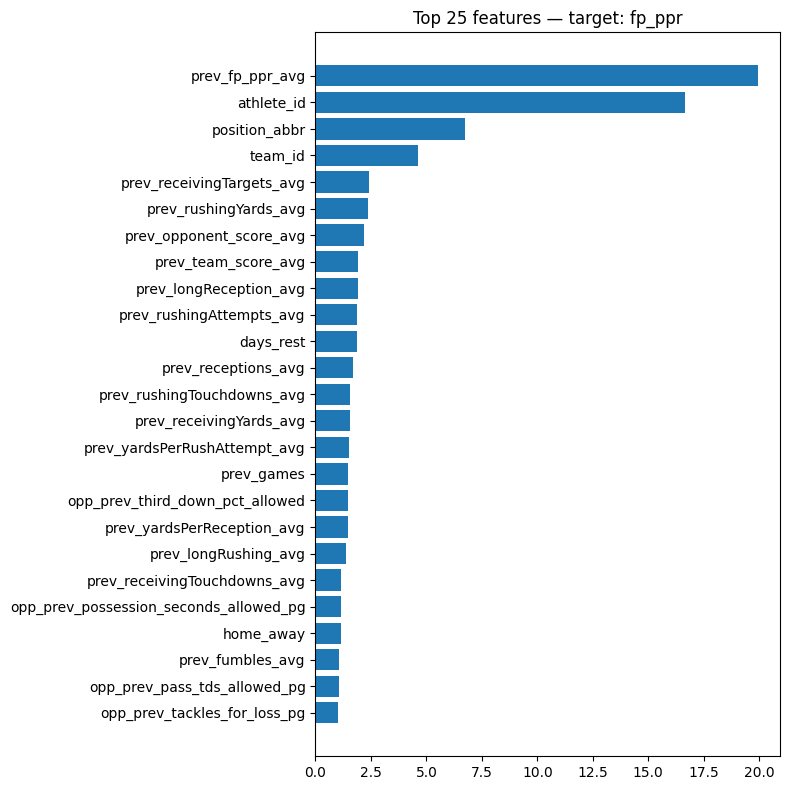

In [11]:
imp = (
    pd.DataFrame({"feature": FEATURE_COLS,
                  "importance": model.get_feature_importance(train_pool)})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top = imp.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top["feature"], top["importance"])
ax.set_title(f"Top 25 features — target: {TARGET}")
fig.tight_layout()

imp.head(25)